# Visualizations

## Reddit

In [1]:
from Config.config import CONFIG
CONFIG = CONFIG("Reddit")

In [ ]:
from Evaluation.utils import load_results, create_diagrams,calc_auc

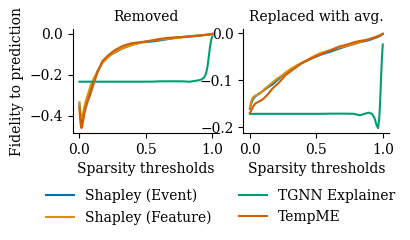

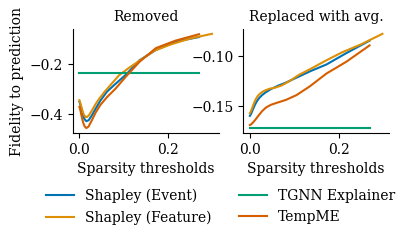

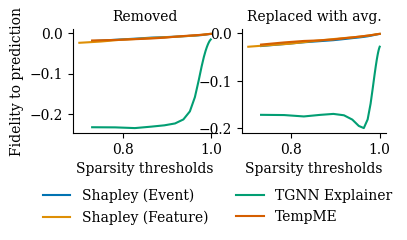

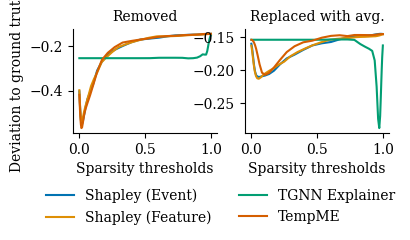

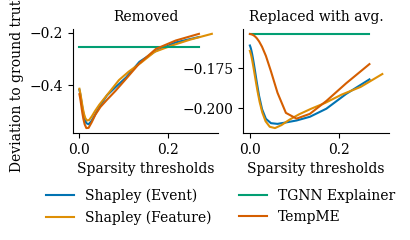

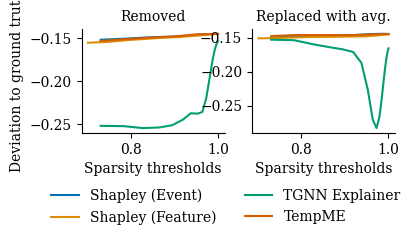

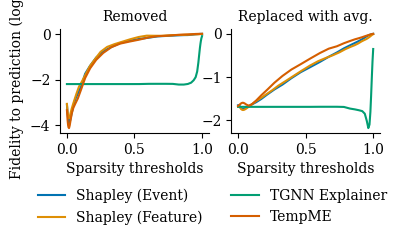

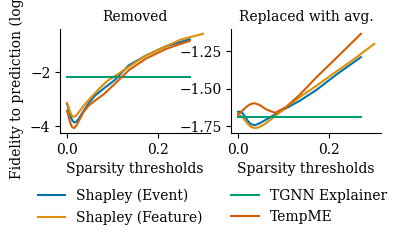

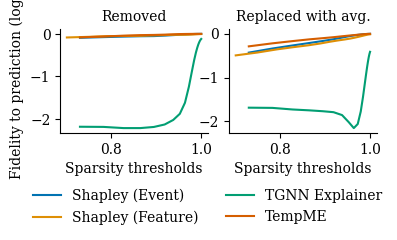

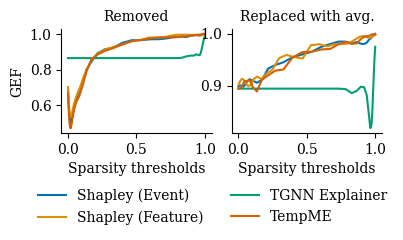

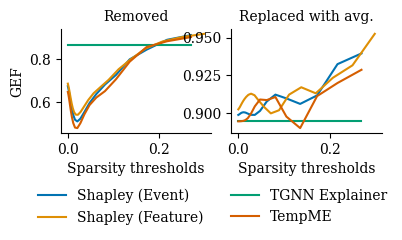

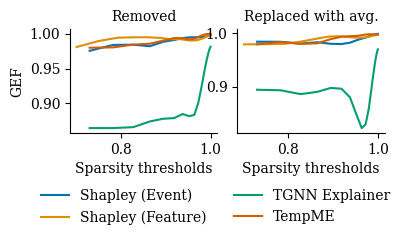

In [3]:
df = load_results(CONFIG.data.dataset_name)
create_diagrams(df, CONFIG.data.dataset_name)

In [4]:
import numpy as np

results_list = load_results(CONFIG.data.dataset_name, as_df=False)

auc_fid_log_zero = calc_auc(results_list, "Fidelity to prediction (logit)", "Zero", no_adjust=True)
auc_fid_log_mean = calc_auc(results_list, "Fidelity to prediction (logit)", "Mean", no_adjust=True)
auc_fid_zero = calc_auc(results_list, "Fidelity to prediction", "Zero", no_adjust=True)
auc_fid_mean = calc_auc(results_list, "Fidelity to prediction", "Mean", no_adjust=True)
auc_dev_zero = calc_auc(results_list, "Deviation to ground truth", "Zero", no_adjust=True)
auc_dev_mean = calc_auc(results_list, "Deviation to ground truth", "Mean", no_adjust=True)
auc_gef_zero = calc_auc(results_list, "GEF", "Zero", no_adjust=True)
auc_gef_mean = calc_auc(results_list, "GEF", "Mean", no_adjust=True)
auc_acc_zero = calc_auc(results_list, "Accuracy", "Zero", no_adjust=True)
auc_acc_mean = calc_auc(results_list, "Accuracy", "Mean", no_adjust=True)

print(f"AUC for Fidelity (logit) using Zero: {auc_fid_log_zero}")
print(f"AUC for Fidelity (logit) using Mean: {auc_fid_log_mean}")
print("")
print(f"AUC for Fidelity using Zero: {auc_fid_zero}")
print(f"AUC for Fidelity using Mean: {auc_fid_mean}")
print("")
print(f"AUC for Deviation using Zero: {auc_dev_zero}")
print(f"AUC for Deviation using Mean: {auc_dev_mean}")
print("")
print(f"AUC for GEF using Zero: {auc_gef_zero}")
print(f"AUC for GEF using Mean: {auc_gef_mean}")
print("")
print(f"AUC for Accuracy using Zero: {auc_acc_zero}")
print(f"AUC for Accuracy using Mean: {auc_acc_mean}")
     

AUC for Fidelity (logit) using Zero: [np.float64(-0.7113914804063354), np.float64(-0.6598620311058081), np.float64(-2.1331095219427665), np.float64(-0.7485124017911119)]
AUC for Fidelity (logit) using Mean: [np.float64(-0.8637545118023432), np.float64(-0.8628947479217364), np.float64(-1.7019809495869367), np.float64(-0.7353163654963593)]

AUC for Fidelity using Zero: [np.float64(-0.08360651819923978), np.float64(-0.08145457939681494), np.float64(-0.22699046610252524), np.float64(-0.08225230936272224)]
AUC for Fidelity using Mean: [np.float64(-0.05924773157631225), np.float64(-0.05739191555299191), np.float64(-0.17088765429315497), np.float64(-0.06160185590652738)]

AUC for Deviation using Zero: [np.float64(-0.21399472824302207), np.float64(-0.21312407685209103), np.float64(-0.2507691170899909), np.float64(-0.2123463947989077)]
AUC for Deviation using Mean: [np.float64(-0.16826032782320915), np.float64(-0.16799591320938656), np.float64(-0.16019079041831327), np.float64(-0.16101776368127

### Conversion to LaTeX table with best and second best highlighted

In [5]:
import numpy as np

content_zero = []
for expl in range(len(auc_fid_zero)):
    text = ""
    for metric in [auc_fid_zero, auc_fid_log_zero, auc_dev_zero, auc_gef_zero]: 
        # keep four decimal places also trailing zeros
        t = f"{metric[expl]:.4f}"
        ranking = np.sort(metric)
        if metric[expl] == ranking[-1]:  #Check if best
            t = "\\textbf{" + t + "}"
        elif metric[expl] == ranking[-2]:  #Check if second best
            t = "\\underline{" + t + "}"
        text += t + " & "
    text = text[:-3]  # remove last &
    content_zero.append(text)
    
content_mean = []
for expl in range(len(auc_fid_mean)):
    text = ""
    for metric in [auc_fid_mean, auc_fid_log_mean, auc_dev_mean, auc_gef_mean]: 
        # keep four decimal places also trailing zeros
        t = f"{metric[expl]:.4f}"
        ranking = np.sort(metric)
        if metric[expl] == ranking[-1]:  #Check if best
            t = "\\textbf{" + t + "}"
        elif metric[expl] == ranking[-2]:  #Check if second best
            t = "\\underline{" + t + "}"
        text += t + " & "
    text = text[:-3]  # remove last &
    content_mean.append(text)

    
text_zero=f"""
\\parbox[t]{{5mm}}{{\\multirow{{4}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{CONFIG.data.dataset_name}}}}}}} & TGNN Explainer & {content_zero[2]} \\\\
& TempME & {content_zero[3]} \\\\
& Shapley (Event) & {content_zero[0]}\\\\
& Shapley (Feature) & {content_zero[1]}\\\\
"""

print(text_zero)

text_mean=f"""
\\parbox[t]{{5mm}}{{\\multirow{{4}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{CONFIG.data.dataset_name}}}}}}} & TGNN Explainer & {content_mean[2]} \\\\
& TempME & {content_mean[3]} \\\\
& Shapley (Event) & {content_mean[0]} \\\\
& Shapley (Feature) & {content_mean[1]} \\\\
"""

print(text_mean)


\parbox[t]{5mm}{\multirow{4}{*}{\rotatebox[origin=c]{90}{Reddit}}} & TGNN Explainer & -0.2270 & -2.1331 & -0.2508 & 0.8683 \\
& TempME & \underline{-0.0823} & -0.7485 & \textbf{-0.2123} & 0.9063 \\
& Shapley (Event) & -0.0836 & \underline{-0.7114} & -0.2140 & \underline{0.9095}\\
& Shapley (Feature) & \textbf{-0.0815} & \textbf{-0.6599} & \underline{-0.2131} & \textbf{0.9140}\\


\parbox[t]{5mm}{\multirow{4}{*}{\rotatebox[origin=c]{90}{Reddit}}} & TGNN Explainer & -0.1709 & -1.7020 & \textbf{-0.1602} & 0.8922 \\
& TempME & -0.0616 & \textbf{-0.7353} & \underline{-0.1610} & 0.9528 \\
& Shapley (Event) & \underline{-0.0592} & -0.8638 & -0.1683 & \underline{0.9559} \\
& Shapley (Feature) & \textbf{-0.0574} & \underline{-0.8629} & -0.1680 & \textbf{0.9584} \\

